# Notebook Práctico de Pandas

## 1. Preparación del Entorno

In [ ]:
import pandas as pd
import numpy as np

# Crearemos un DataFrame más completo para los ejemplos
data = {
    'Producto': ['A', 'B', 'A', 'C', 'B', 'A', 'C'],
    'Region': ['Norte', 'Sur', 'Norte', 'Este', 'Sur', 'Oeste', 'Norte'],
    'Ventas': [100, 150, 120, 200, 180, 90, 220],
    'Costos': [80, 120, 90, 150, 150, 70, 170]
}
df = pd.DataFrame(data)
df

---

## 2. Métodos Exploratorios Comunes

Estos métodos son esenciales para tener una primera vista de tus datos.

In [ ]:
# .head(): Muestra las primeras 5 filas por defecto
df.head()



In [ ]:
# .head(n): Muestra las primeras 'n' filas
df.head(2)

In [ ]:
# .tail(): Muestra las últimas 5 filas por defecto
display(df.tail())

In [ ]:
# .tail(n): Muestra las últimas 'n' filas
display(df.tail(3))

In [ ]:
df.describe()

---

## 3. Estadísticas Descriptivas

Calcula resúmenes estadísticos de tus datos.

In [ ]:
# .mean(): Calcula el promedio de las columnas numéricas
print(df[['Ventas', 'Costos']].mean())

In [ ]:
# También se puede aplicar a una sola columna (Serie)
promedio_ventas = df['Ventas'].mean()
print(f"\nEl promedio de ventas es: {promedio_ventas:.2f}")

---

## 4. Slicing: Selección Avanzada de Datos

Slicing es la técnica para seleccionar subconjuntos de datos (porciones de la tabla). Se usan principalmente `.loc` e `.iloc`.

- **`.loc[filas, columnas]`**: Selección por **ETIQUETA**. El rango final SÍ se incluye.
- **`.iloc[filas, columnas]`**: Selección por **POSICIÓN**. El rango final NO se incluye.

In [ ]:
# --- Ejemplos con .iloc (basado en POSICIÓN) ---
print("--- .iloc: Fila en posición 1 ---")
display(df.iloc[1])

In [ ]:
# Fila en posición 1, columna en posición 2 ('Ventas')
df.iloc[1, 2]

In [ ]:
# Primeras 3 filas y primeras 2 columnas
df.iloc[0:3, 0:2]

In [ ]:
df.loc[0:2,'Producto':'Costos']

In [ ]:
# --- Ejemplos con .loc (basado en ETIQUETA) ---
# Para que sea más claro, asignamos etiquetas de índice personalizadas
df.index = ['Fila_A', 'Fila_B', 'Fila_C', 'Fila_D', 'Fila_E', 'Fila_F', 'Fila_G']

print("--- DataFrame con nuevo índice ---")
display(df.head())

# Fila con la etiqueta 'Fila_B'
print("\n--- .loc: Fila con etiqueta 'Fila_B' ---")
display(df.loc[['Fila_B']])

# Filas desde 'Fila_B' hasta 'Fila_D' y columnas 'Producto' y 'Ventas'
print("\n--- .loc: Slicing de filas y columnas por etiqueta ---")
display(df.loc['Fila_B':'Fila_D', ['Producto', 'Ventas']])

#Renombrar columnas


In [ ]:
df.rename(columns={'Ventas': 'Ventas_Totales'}, inplace=True)
df

## 5.Agrupacion y Agregaciones

In [ ]:
df

In [ ]:
# .agg(): Permite aplicar una o varias funciones de agregación

# Ejemplo 1: Aplicar múltiples funciones a la columna 'Ventas' agrupando por Productos
agregaciones_ventas = df.groupby('Producto')['Ventas'].agg(['sum', 'mean', 'min', 'max'])
print("--- Agregaciones para 'Ventas' ---")
display(agregaciones_ventas)



In [ ]:
# Ejemplo 2: Aplicar diferentes funciones a diferentes columnas
agregaciones_multiples = df.agg({
    'Ventas': ['sum', 'mean'],
    'Costos': ['mean', 'std']
})
print("\n--- Diferentes agregaciones por columna ---")
agregaciones_multiples

In [ ]:
# Ejemplo 2: Aplicar diferentes funciones a diferentes columnas
agregaciones_multiples = df.groupby('Producto').agg({
    'Ventas': ['sum', 'mean'],
    'Costos': ['mean', 'std']
})
print("\n--- Diferentes agregaciones por columna ---")
agregaciones_multiples

##6.Calculo de columnas

In [ ]:
# Ejemplo 1: Calcular la ganancia (Ventas - Costos)
# Se crea una nueva columna llamada 'Ganancia'
df['Ganancia'] = df['Ventas'] - df['Costos']
df



In [ ]:
# Ejemplo 2: Calcular el margen de ganancia en porcentaje
# Se crea la columna 'Margen_%'
df['Margen_%'] = (df['Ganancia'] / df['Ventas']) * 100
print("\n--- DataFrame con columna 'Margen_%' ---")
# Usamos .round(2) para redondear el resultado a 2 decimales
df.round(2)

In [ ]:
df.to_excel("Ventas.xlsx")

##8.Visualización

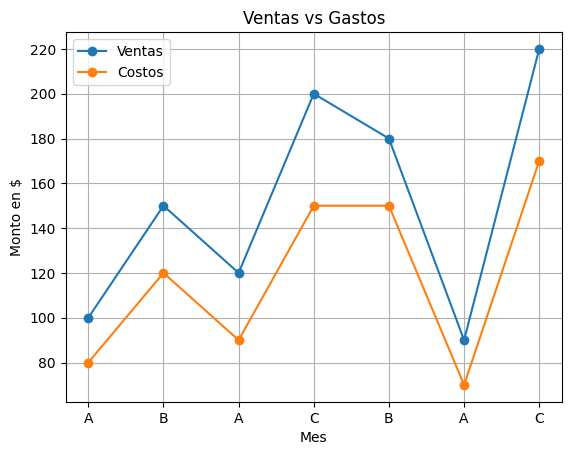

In [ ]:
import matplotlib.pyplot as plt

df.plot(x="Producto", y=["Ventas", "Costos"], kind="line", marker="o")
plt.title("Ventas vs Gastos")
plt.xlabel("Mes")
plt.ylabel("Monto en $")
plt.grid(True)
plt.show()

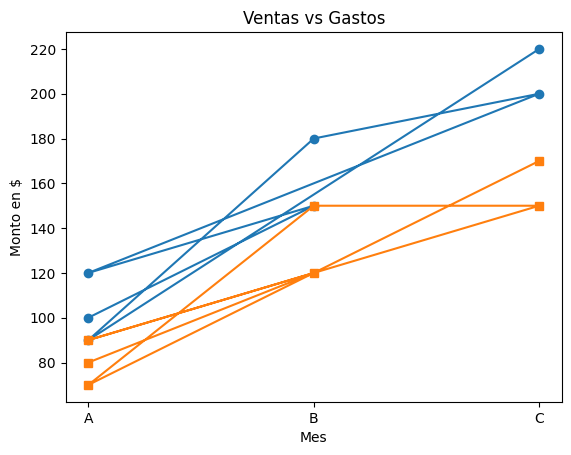

In [ ]:
# Creamos la figura
plt.plot(df['Producto'], df['Ventas'], marker="o", label="Ventas")
plt.plot(df['Producto'], df['Costos'], marker="s", label="Gastos")

plt.title("Ventas vs Gastos")
plt.xlabel("Mes")
plt.ylabel("Monto en $")

plt.show()
